# Worked Example: PSD and FOOOF Reward Contrast

## Goal
Compare reward vs no-reward spectra on feedback epochs. FOOOF uses `analysis_utils` — see {doc}`11_advanced_utility_interoperability`.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from LFPAnalysis import load_lfp
from LFPAnalysis.config import LoadConfig

beh = pd.read_csv(Path('../../data/sample_beh.csv'))
epochs = load_lfp(LoadConfig(path=Path('../../data/sample_feedback_start-epo.fif'), file_format='mne', preload=True))
epochs.metadata = beh[['reward', 'rpe']]
chan = 'racas1-racas2'
reward_psd = epochs['reward == 1'].copy().pick([chan]).compute_psd(fmin=1, fmax=80, verbose=False)
loss_psd = epochs['reward == 0'].copy().pick([chan]).compute_psd(fmin=1, fmax=80, verbose=False)

Reading /Users/salmanqasim/Documents/GitRepos/LFPAnalysis/data/sample_feedback_start-epo.fif ...
    Found the data of interest:
        t =   -1500.00 ...    2500.00 ms
        0 CTF compensation matrices available
Not setting metadata
80 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 2 columns


## Plot PSD contrast

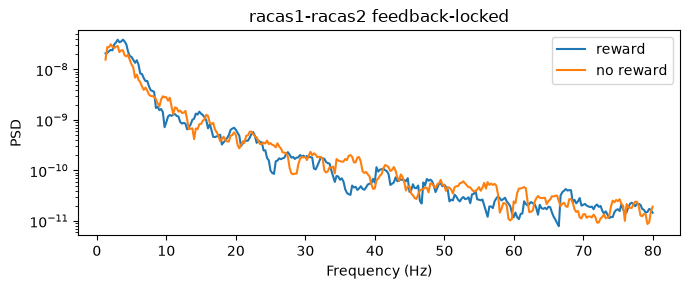

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(reward_psd.freqs, reward_psd.get_data()[0, 0], label='reward')
ax.semilogy(loss_psd.freqs, loss_psd.get_data()[0, 0], label='no reward')
ax.set(xlabel='Frequency (Hz)', ylabel='PSD', title=f'{chan} feedback-locked')
ax.legend()
fig.tight_layout()
plt.show()

## FOOOF via advanced utility (subset for speed)

In [5]:
from LFPAnalysis import analysis_utils

epochs_sub = epochs.copy().pick([chan])[:10]
fooof_kwargs = {
    'peak_width_limits': (1, 12),
    'min_peak_height': 0.0,
    'peak_threshold': 2.0,
    'max_n_peaks': 6,
    'freq_range': (1, 40),
}
_, fooof_table = analysis_utils.FOOOF_compute_epochs(
    epochs_sub, tmin=float(epochs_sub.times[0]), tmax=float(epochs_sub.times[-1]), **fooof_kwargs
)
print(fooof_table.head())

         channel  frequency   PSD_raw  PSD_corrected  in_FOOOF_peak  \
0  racas1-racas2   1.249375 -7.408953      -0.195834            0.0   
1  racas1-racas2   1.499250 -7.562092      -0.200702            0.0   
2  racas1-racas2   1.749125 -7.624555      -0.137804            0.0   
3  racas1-racas2   1.999000 -7.696497      -0.101153            0.0   
4  racas1-racas2   2.248876 -7.699291      -0.008161            0.0   

   peak_freq  peak_height   PSD_exp  
0        0.0          0.0  1.872549  
1        0.0          0.0  1.872549  
2        0.0          0.0  1.872549  
3        0.0          0.0  1.872549  
4        0.0          0.0  1.872549  


## Next step

Advanced utility interoperability: 11_advanced_utility_interoperability. Next chapter: time-frequency.